# Credit risk scorecard: probability of default on 1.35 million LendingClub loans

Logistic-regression scorecard built with practices used for regulatory (IRB-style) credit risk models:
data checks against the data dictionary, variables known at origination only, optimal monotonic binning with weight of evidence (WoE), a sign-constrained L1-penalised logistic regression,
out-of-time validation, long-run-average calibration with a margin of conservatism, and stability monitoring (PSI).

## 1. Setup

In [2]:
import gc
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from optbinning import OptimalBinning
from scipy.optimize import brentq, minimize
from scipy.special import expit
from scipy.stats import gaussian_kde, ks_2samp
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [3]:
# Paths (works from the repo root or from notebooks/)
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir

DATA_RAW = project_root / 'data' / 'raw'
DATA_CLEANED = project_root / 'data' / 'cleaned'
DATA_PROCESSED = project_root / 'data' / 'processed'
DATA_CLEANED.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Figures used in the README
FIGURES = project_root / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# Out-of-time split: train on loans issued before this date, validate on loans issued after
OOT_CUTOFF = pd.Timestamp('2015-01-01')

## 2. Load data and check it against the data dictionary

In [4]:
FILE_PATH_DATA = DATA_RAW / 'accepted_2007_to_2018Q4.csv.gz'
# Data dictionary: LendingClub's LoanStats sheet (variable name, description), saved as CSV in metadata/
FILE_PATH_DICTIONARY = project_root / 'metadata' / 'dictionary_approved_raw.csv'

df = pd.read_csv(FILE_PATH_DATA, compression='gzip', low_memory=False)

if FILE_PATH_DICTIONARY.exists():
    df_dictionary = pd.read_csv(FILE_PATH_DICTIONARY, usecols=[0, 1], low_memory=False)
else:
    df_dictionary = None
    print(f"Data dictionary not found at {FILE_PATH_DICTIONARY}; skipping the dictionary check.")

In [5]:
# Comparing data to dictionary

if df_dictionary is not None:
    data_columns = set(df.columns)
    dictionary_columns = set(df_dictionary.iloc[:, 0].astype(str).str.strip())

    common = data_columns.intersection(dictionary_columns)
    in_data_only = data_columns - dictionary_columns
    in_dict_only = dictionary_columns - data_columns

    print(f"Total columns in Dataset: {len(data_columns)}")
    print(f"Total variables in Dictionary: {len(dictionary_columns)}")
    print(f"Matches found: {len(common)}\n")

    print("-" * 30)
    print(f"Columns in DATA but not in Dictionary ({len(in_data_only)}):")
    print(list(in_data_only))

    print("-" * 30)
    print(f"Columns in DICTIONARY but not in Data ({len(in_dict_only)}):")
    print(list(in_dict_only))

Total columns in Dataset: 151
Total variables in Dictionary: 152
Matches found: 150

------------------------------
Columns in DATA but not in Dictionary (1):
['verification_status_joint']
------------------------------
Columns in DICTIONARY but not in Data (2):
[nan, 'verified_status_joint']


In [6]:
# Make sure the names of the features match, then save the cleaned dictionary

if df_dictionary is not None:
    df_dictionary.iloc[:, 0] = df_dictionary.iloc[:, 0].replace('verified_status_joint', 'verification_status_joint')
    df_dictionary = df_dictionary.dropna()

    # Save cleaned dictionary
    FILE_PATH_DICTIONARY_CLEANED = project_root / 'data' / 'cleaned'/ 'dictionary_approved_cleaned.csv'

    df_dictionary.to_csv(FILE_PATH_DICTIONARY_CLEANED)

## 3. Select variables known at origination

Only information available when the loan is issued is kept. LendingClub's own grade and interest rate are excluded,
so the model cannot simply copy the lender's risk assessment.

In [7]:
cols_to_keep = [
    # Target
    'loan_status',

    # Structural / Lender Features (Known at Origination)
    'term', 'loan_amnt', 'initial_list_status', 'application_type', 'installment',

    # Applicant Features (The core data)
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'mths_since_last_delinq',
    'fico_range_low', 'fico_range_high',

    # Dates
    'issue_d', 'earliest_cr_line'
]
df = df[cols_to_keep]

# Midpoint of the reported FICO range
df['fico_average'] = (df['fico_range_high'] + df['fico_range_low']) / 2
df = df.drop(columns = ['fico_range_high', 'fico_range_low'])

In [8]:
# Checking data types for cleaning

print(df.dtypes)

object_cols = df.select_dtypes(include=['object', 'string']).columns

for col in object_cols:
    num_unique = df[col].nunique()
    
    print(f"Column: {col}")
    print(f"Count of unique values: {num_unique}")
    
    if num_unique < 50:
        print(f"Values: {df[col].unique()}")
    else:
        print(f"Top 10 values: {df[col].value_counts().head(10).index.tolist()}")
    
    print("-" * 30)

loan_status                   str
term                          str
loan_amnt                 float64
initial_list_status           str
application_type              str
installment               float64
emp_length                    str
home_ownership                str
annual_inc                float64
verification_status           str
purpose                       str
dti                       float64
delinq_2yrs               float64
inq_last_6mths            float64
open_acc                  float64
pub_rec                   float64
revol_bal                 float64
revol_util                float64
total_acc                 float64
mort_acc                  float64
pub_rec_bankruptcies      float64
mths_since_last_delinq    float64
issue_d                       str
earliest_cr_line              str
fico_average              float64
dtype: object
Column: loan_status
Count of unique values: 9
Values: <StringArray>
[                                         'Fully Paid',
            

## 4. Define default and encode variables

Only closed loans are kept. Default = charged off or in default.

In [9]:
# Turning all variables into int or float usable types

target_statuses = [
    'Fully Paid', 
    'Charged Off', 
    'Default', 
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]

df = df[df['loan_status'].isin(target_statuses)].copy()

# target
bad_indicators = [
    'Charged Off', 
    'Default', 
    'Does not meet the credit policy. Status:Charged Off',
]
df['target'] = np.where(df['loan_status'].isin(bad_indicators), 1, 0)
df = df.drop(columns=['loan_status'])

term_map = {' 36 months': 1, ' 60 months': 2}
df['term_rank'] = df['term'].map(term_map)
df = df.drop(columns=['term'])

initial_list_status_map = {'w': 0, 'f': 1}
df['initial_list_status_f'] = df['initial_list_status'].map(initial_list_status_map)
df = df.drop(columns=['initial_list_status'])

application_type_map = {'Joint App': 0, 'Individual': 1}
df['individual_application'] = df['application_type'].map(application_type_map)
df = df.drop(columns=['application_type'])

df['emp_length_years'] = df['emp_length'].str.replace('< 1', '0').str.extract(r'(\d+)')
df['emp_length_years'] = pd.to_numeric(df['emp_length_years'], errors='coerce')
df = df.drop(columns=['emp_length'])

dummy_cols = ['home_ownership', 'purpose', 'verification_status']
df = pd.get_dummies(df, columns=dummy_cols, drop_first=True, dtype=int)

# Engineering date to get months of credit history
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_hist_months'] = ((df['issue_d'] - df['earliest_cr_line']) / pd.Timedelta(days=30))

# Normalise column names
df.columns = df.columns.str.replace(' ', '_').str.lower()


categorical_columns = [
    'target',
    'term_rank',
    'initial_list_status_f',
    'individual_application',
    'emp_length_years',
    'home_ownership_mortgage', 
    'home_ownership_none',
    'home_ownership_other',
    'home_ownership_own',
    'home_ownership_rent',
    'verification_status_source_verified',
    'verification_status_verified',
    'purpose_credit_card',
    'purpose_debt_consolidation',
    'purpose_educational',
    'purpose_home_improvement',
    'purpose_house',
    'purpose_major_purchase',
    'purpose_medical',
    'purpose_moving',
    'purpose_other',
    'purpose_renewable_energy',
    'purpose_small_business',
    'purpose_vacation',
    'purpose_wedding'
]

missing_categorical_cols = [col for col in categorical_columns if col not in df.columns]

if missing_categorical_cols:
    print(f"Warning: The following columns were not found in df: {missing_categorical_cols}")
else:
    print("All columns present")
    print(df.dtypes)

All columns present
loan_amnt                                     float64
installment                                   float64
annual_inc                                    float64
dti                                           float64
delinq_2yrs                                   float64
inq_last_6mths                                float64
open_acc                                      float64
pub_rec                                       float64
revol_bal                                     float64
revol_util                                    float64
total_acc                                     float64
mort_acc                                      float64
pub_rec_bankruptcies                          float64
mths_since_last_delinq                        float64
issue_d                                datetime64[us]
earliest_cr_line                       datetime64[us]
fico_average                                  float64
target                                          int64
term_ran

## 5. Candidate features: pairwise products and ratios, screened by information value

All pairwise products and ratios of the base variables are generated and screened in parallel.
Information value is computed on **training-period loans only**, so the out-of-time sample plays no part in feature selection.

In [10]:
# Brute force feature engineering

# Configuration
IV_THRESHOLD = 0.02
N_JOBS = 8

# Setup Data
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype(np.float32)

target = df['target'].values
train_mask = (df['issue_d'] < OOT_CUTOFF).values   # screen on training period only
target_train = target[train_mask]
non_predictive = ['target', 'issue_d', 'earliest_cr_line']
features = [col for col in df.columns if col not in non_predictive]

print(f"Starting parallel IV screening on {len(features)} base features...")

# Worker Function
def process_pair_ops(v1, v2, col_v1, col_v2, target_train, train_mask, threshold):
    results = []
    
    # Context manager suppresses "RuntimeWarning: divide by zero encountered"
    with np.errstate(divide='ignore', invalid='ignore'):
        ops = {
            f"{v1}_x_{v2}": col_v1 * col_v2,
            f"{v1}_div_{v2}": col_v1 / col_v2,
        }

    for name, data in ops.items():
        try:
            if np.isnan(data).all():
                continue

            optb = OptimalBinning(
                name=name,
                dtype="numerical",
                solver="cp",
                monotonic_trend="auto_asc_desc",
                min_bin_size=0.05,
                max_pvalue=0.05
            )
            
            # If infs cause fitting issues, the try-except block will catch it and skip
            optb.fit(data[train_mask], target_train)
            iv = optb.binning_table.build().loc['Totals', 'IV']
            
            if iv > threshold:
                results.append((name, iv, data))
                
        except Exception:
            # Optbinning may fail on specific distributions of inf; we skip those.
            continue
            
    return results if results else None

# Parallel Execution
results_nested = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(process_pair_ops)(
        v1, v2, df[v1].values, df[v2].values, target_train, train_mask, IV_THRESHOLD
    ) for v1, v2 in combinations(features, 2)
)

# Aggregation
valid_results = []
if results_nested:
    for res in results_nested:
        if res:
            valid_results.extend(res)

if valid_results:
    # Unpack results
    names = [r[0] for r in valid_results]
    iv_values = [r[1] for r in valid_results]
    data_arrays = [r[2] for r in valid_results]
    
    # Create DataFrames
    df_new_features = pd.DataFrame(dict(zip(names, data_arrays)), index=df.index)
    df_iv_summary = pd.DataFrame({'feature': names, 'iv': iv_values}).sort_values('iv', ascending=False)
    
    # Merge
    df = pd.concat([df, df_new_features], axis=1)
    
    print("\nProcessing Complete.")
    print(f"Total new features added: {len(df_new_features.columns)}")
    print(df_iv_summary.head(10))
else:
    print("\nNo features met the threshold.")

Starting parallel IV screening on 40 base features...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:    2.5s
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed:    6.2s
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed:   10.9s
[Parallel(n_jobs=8)]: Done 272 tasks      | elapsed:   14.9s
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:   21.5s
[Parallel(n_jobs=8)]: Done 632 tasks      | elapsed:   26.4s
[Parallel(n_jobs=8)]: Done 780 out of 780 | elapsed:   30.7s finished



Processing Complete.
Total new features added: 113
                                    feature        iv
93               fico_average_div_term_rank  0.317845
102      term_rank_x_individual_application  0.195354
92                 fico_average_x_term_rank  0.195354
103    term_rank_div_individual_application  0.195354
1                 loan_amnt_div_installment  0.193701
44                          dti_x_term_rank  0.192943
30                 annual_inc_div_term_rank  0.190533
74                   revol_util_x_term_rank  0.163990
107  term_rank_x_purpose_debt_consolidation  0.124681
10                    loan_amnt_x_term_rank  0.123100


## 6. Out-of-time split

In [11]:
df_train = df[df['issue_d'] < OOT_CUTOFF].copy()
df_oot = df[df['issue_d'] >= OOT_CUTOFF].copy()

print("\n--- Split Summary ---")
print(f"Train/Test Volume: {len(df_train)}")
print(f"OOT Volume: {len(df_oot)}")
print(f"OOT Default Rate: {df_oot['target'].mean():.2%}")

df = df.drop(columns=['issue_d', 'earliest_cr_line'])
issue_dates_train = df_train['issue_d']
df_train = df_train.drop(columns=['issue_d', 'earliest_cr_line'])
df_oot = df_oot.drop(columns=['issue_d', 'earliest_cr_line'])


--- Split Summary ---
Train/Test Volume: 453809
OOT Volume: 894290
OOT Default Rate: 21.48%


In [12]:
# Proportion of target values

print(f"Filtered Shape: {df.shape}")
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True))

Filtered Shape: (1348099, 154)

Target Distribution:
target
0    0.800193
1    0.199807
Name: proportion, dtype: float64


In [13]:
# Save checkpoints (ignored by git)
df_train.to_pickle(DATA_PROCESSED / 'data_train.pkl')
df_oot.to_pickle(DATA_PROCESSED / 'data_oot.pkl')

## 7. Optimal binning, weight of evidence and information value

Bins are fitted on the training sample only and then applied unchanged to the out-of-time sample.
Variables with information value between 0.02 and 1.0 are kept (above 1.0 usually signals leakage).

In [14]:
# Identify Categorical vs Numerical variables
target_col = 'target'

# Select features (excluding target and ignored cols)
features = [c for c in df_train.columns if c not in [target_col]]

num_cols = df_train[features].select_dtypes(include=['number']).columns.tolist()

In [ ]:
binning_process = {}
iv_summary = []

# A ratio with a zero denominator is undefined: treat +/-inf as missing in both samples, so those loans fall in the Missing bin in train and OOT alike
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_oot = df_oot.replace([np.inf, -np.inf], np.nan)

for col in features:
    # Configuration
    dtype = "categorical" if col in categorical_columns else "numerical"
    
    # Enforce Monotonicity for numerical variables
    optb = OptimalBinning(
        name=col, 
        dtype=dtype, 
        solver="cp",
        monotonic_trend="auto_asc_desc",
        min_bin_size = 0.05,
        max_pvalue = 0.05
    )

    # Fit the Binner
    try:
        optb.fit(df_train[col], df_train[target_col])
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")
        continue

    # Store Results
    binning_process[col] = optb
    
    # Get IV
    binning_table = optb.binning_table.build()
    iv = binning_table.loc['Totals', 'IV']
    iv_summary.append({'Variable': col, 'IV': iv})

In [16]:
df_iv = pd.DataFrame(iv_summary).sort_values('IV', ascending=False)

print("\n--- Top Predictive Variables (IV) ---")
print(df_iv.head(10))

selected_vars = df_iv[(df_iv['IV'] >= 0.02) & (df_iv['IV'] < 1.0)]['Variable'].tolist()
print(f"\nSelected {len(selected_vars)} variables for the Scorecard.")


--- Top Predictive Variables (IV) ---
                                   Variable        IV
133              fico_average_div_term_rank  0.317845
132                fico_average_x_term_rank  0.195354
143    term_rank_div_individual_application  0.195354
142      term_rank_x_individual_application  0.195354
15                                term_rank  0.195354
41                loan_amnt_div_installment  0.193701
84                          dti_x_term_rank  0.192943
70                 annual_inc_div_term_rank  0.190533
114                  revol_util_x_term_rank  0.163990
147  term_rank_x_purpose_debt_consolidation  0.124681

Selected 121 variables for the Scorecard.


In [ ]:
# Transform both train and OOT datasets using the bins learned from train 

train_cols, oot_cols = {}, {}
for col in selected_vars:
    optb = binning_process[col]
    train_cols[col] = optb.transform(df_train[col], metric="woe", metric_missing="empirical")
    oot_cols[col] = optb.transform(df_oot[col], metric="woe", metric_missing="empirical")

X_train_woe = pd.DataFrame(train_cols, index=df_train.index)
X_oot_woe = pd.DataFrame(oot_cols, index=df_oot.index)

# Add target back for modelling convenience
X_train_woe['target'] = df_train[target_col].values
X_oot_woe['target'] = df_oot[target_col].values

## 8. Remove redundant variables

First near-duplicates (|correlation| > 0.99), then variance inflation factors above 10.
When a choice is needed, derived features are dropped before original variables.

In [18]:
# Calculate Correlation Matrix (features only, not the target)
corr_matrix = X_train_woe.drop(columns=['target']).corr().abs()

# Identify Correlated Pairs
# Select upper triangle to avoid duplicates (A-B and B-A) and self-correlation
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Filter for correlation > 0.99
high_corr_pairs = upper_tri.stack()
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.99].index.tolist()

# Custom Filtering Logic
to_drop = set()

for col_a, col_b in high_corr_pairs:
    # If one of the pair is already marked for dropping, the conflict is resolved
    if col_a in to_drop or col_b in to_drop:
        continue
    
    # Check if features are "interaction" terms
    a_is_inter = '_x_' in col_a or '_div_' in col_a
    b_is_inter = '_x_' in col_b or '_div_' in col_b
    
    # Prioritise dropping interaction terms over standard terms
    if a_is_inter and not b_is_inter:
        to_drop.add(col_a)
    elif b_is_inter and not a_is_inter:
        to_drop.add(col_b)
    else:
        # Drop the second one (col_b) to maintain consistent order
        to_drop.add(col_b)

print(f"Dropping {len(to_drop)} identical/highly correlated features.")
print(list(to_drop))

# Drop Features
X_train_woe = X_train_woe.drop(columns=to_drop)
X_oot_woe = X_oot_woe.drop(columns=to_drop)

Dropping 20 identical/highly correlated features.
['fico_average_div_individual_application', 'fico_average_x_term_rank', 'mort_acc_div_fico_average', 'inq_last_6mths_div_individual_application', 'mort_acc_x_individual_application', 'annual_inc_div_individual_application', 'fico_average_x_individual_application', 'revol_util_x_individual_application', 'inq_last_6mths_x_individual_application', 'dti_div_individual_application', 'term_rank_div_individual_application', 'loan_amnt_div_individual_application', 'loan_amnt_x_individual_application', 'term_rank_x_individual_application', 'revol_util_div_individual_application', 'dti_x_individual_application', 'inq_last_6mths_x_fico_average', 'loan_amnt_div_installment', 'mort_acc_div_individual_application', 'annual_inc_x_individual_application']


In [ ]:
def filter_vif_prioritised_fast(X, threshold=10.0):
    """
    Fast VIF filtering using Matrix Inversion.
    Avoids iterative OLS regressions by utilizing the inverse correlation matrix property.
    Prioritises dropping interaction terms ('_x_', '_div_').
    """
    # Calculate Correlation Matrix (Expensive step, done once)
    corr_matrix = X.corr()
    
    # Track columns to keep
    keep_cols = list(corr_matrix.columns)
    
    print(f"Initial feature count: {len(keep_cols)}")
    
    while True:
        # Subset the correlation matrix to current features
        C = corr_matrix.loc[keep_cols, keep_cols]
        
        # Calculate VIF via Inverse Matrix
        try:
            # The diagonal of the inverse correlation matrix is the VIF
            inv_C = np.linalg.inv(C.values)
            vif_values = np.diag(inv_C)
        except np.linalg.LinAlgError:
            # If matrix is singular, identify feature with highest R^2 with others
            print("Matrix singular. Dropping variable with highest global correlation.")
            corr_sum = C.abs().sum()
            drop_col = corr_sum.idxmax()
            print(f"Dropping (Singularity Fix): {drop_col}")
            keep_cols.remove(drop_col)
            continue

        # Map VIFs to feature names
        vif_series = pd.Series(vif_values, index=keep_cols)
        
        # Check Threshold
        max_vif = vif_series.max()
        if max_vif <= threshold:
            break
            
        # Filter variables exceeding threshold
        high_vif_vars = vif_series[vif_series > threshold]
        
        # Identify interactions
        is_interaction = high_vif_vars.index.str.contains('_x_|_div_')
        interactions_over_limit = high_vif_vars[is_interaction]
        
        if not interactions_over_limit.empty:
            # Drop worst interaction term
            drop_col = interactions_over_limit.idxmax()
            drop_vif = interactions_over_limit.max()
            print(f"Dropping INTERACTION: {drop_col} (VIF={drop_vif:.2f})")
        else:
            # Drop worst standard term
            drop_col = high_vif_vars.idxmax()
            drop_vif = high_vif_vars.max()
            print(f"Dropping STANDARD:    {drop_col} (VIF={drop_vif:.2f})")
            
        keep_cols.remove(drop_col)
    
    print(f"Final feature count: {len(keep_cols)}")
    return X[keep_cols]

# Apply to the features only
X_train_vif = filter_vif_prioritised_fast(X_train_woe.drop(columns=['target']), threshold=10.0)

# Keep the same columns, plus the target, in train and Test/OOT
kept_columns = X_train_vif.columns.tolist() + ['target']
X_train_woe = X_train_woe[kept_columns]
X_oot_woe = X_oot_woe[kept_columns]

Initial feature count: 101
Dropping INTERACTION: dti_div_fico_average (VIF=56.45)
Dropping INTERACTION: dti_x_fico_average (VIF=49.66)
Dropping INTERACTION: annual_inc_x_fico_average (VIF=43.40)
Dropping INTERACTION: revol_util_x_fico_average (VIF=41.82)
Dropping INTERACTION: fico_average_div_term_rank (VIF=38.04)
Dropping INTERACTION: annual_inc_div_fico_average (VIF=35.91)
Dropping INTERACTION: loan_amnt_x_dti (VIF=35.50)
Dropping INTERACTION: loan_amnt_x_revol_util (VIF=32.83)
Dropping INTERACTION: revol_util_div_fico_average (VIF=29.20)
Dropping INTERACTION: inq_last_6mths_x_open_acc (VIF=25.08)
Dropping INTERACTION: loan_amnt_div_fico_average (VIF=24.80)
Dropping INTERACTION: installment_x_inq_last_6mths (VIF=23.81)
Dropping INTERACTION: dti_x_open_acc (VIF=22.40)
Dropping INTERACTION: loan_amnt_x_fico_average (VIF=22.27)
Dropping INTERACTION: installment_div_annual_inc (VIF=20.12)
Dropping INTERACTION: loan_amnt_x_open_acc (VIF=18.30)
Dropping INTERACTION: mort_acc_x_credit_hist_

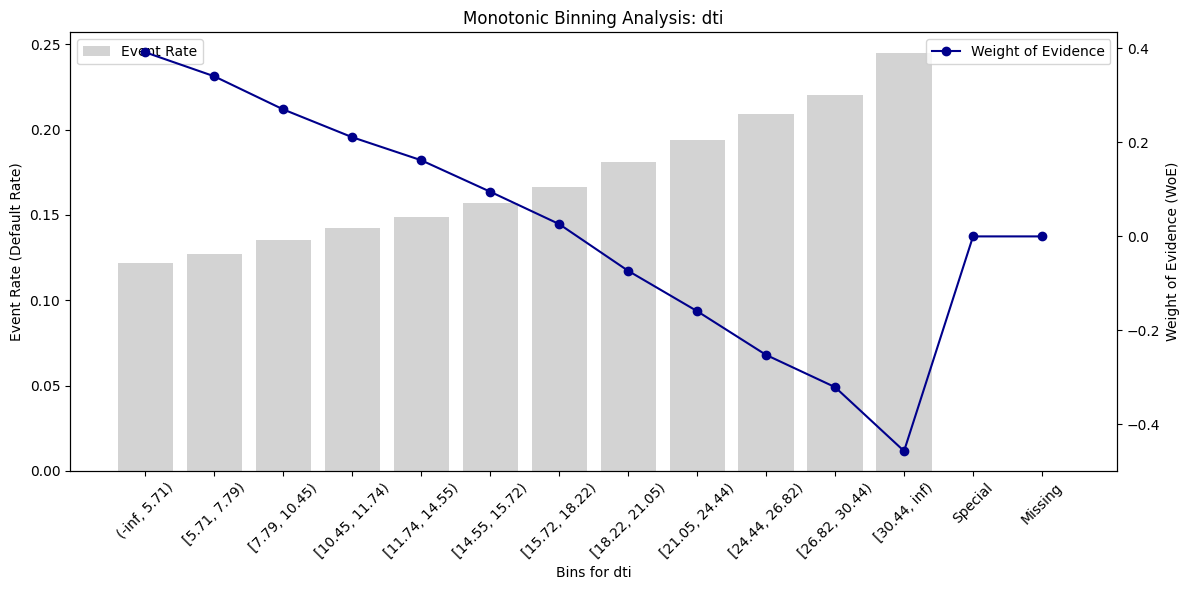

In [20]:
# Plot the binning table for a specified variable

variable = 'dti'
optb = binning_process[variable]
table = optb.binning_table.build()

# Remove the 'Totals' row
plot_table = table.iloc[:-1, :].copy()

# Ensure 'Bin' is treated as string for categorical plotting
bin_labels = plot_table['Bin'].astype(str).tolist()
x_pos = np.arange(len(bin_labels))

fig, ax1 = plt.subplots(figsize=(12, 6))

# Use x_pos for bar placement
ax1.bar(x_pos, plot_table['Event rate'], color='lightgrey', label='Event Rate')
ax1.set_ylabel('Event Rate (Default Rate)')
ax1.set_xlabel(f'Bins for {variable}')

# Align xticks with labels
ax1.set_xticks(x_pos)
ax1.set_xticklabels(bin_labels, rotation=45)

# Line chart for WoE
ax2 = ax1.twinx()
ax2.plot(x_pos, plot_table['WoE'], marker='o', color='darkblue', label='Weight of Evidence')
ax2.set_ylabel('Weight of Evidence (WoE)')

plt.title(f'Monotonic Binning Analysis: {variable}')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES / 'binning_dti.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sign-constrained L1-penalised logistic regression

Variables are selected using L1-penalised logistic regression

The penalty $\lambda$ is chosen by 5-fold cross-validation on the training loans, using the **one-standard-error rule**:
the largest $\lambda$ (the simplest model) whose cross-validated log-loss is within one standard error of the best.
No p-values are used anywhere.

In [ ]:
# Data for the model
y_train = X_train_woe['target'].to_numpy(dtype=np.float64)
X_train_feats = X_train_woe.drop(columns=['target'])
feature_names = X_train_feats.columns.tolist()
X_tr = X_train_feats.to_numpy(dtype=np.float64)


def fit_sign_constrained_l1(X, y, lam, w0=None):
    """
    Logistic regression with an L1 penalty and all slope coefficients constrained to be <= 0.

    Minimises  mean(log(1 + exp(z)) - y * z) + lam * sum(-beta),  with z = b0 + X @ beta and beta <= 0.
    Returns (intercept, beta).
    """

    from scipy.special import expit

    n, p = X.shape

    def objective(w):
        z = w[0] + X @ w[1:]
        loss = np.mean(np.logaddexp(0.0, z) - y * z)
        resid = expit(z) - y
        grad = np.empty_like(w)
        grad[0] = resid.mean()
        grad[1:] = X.T @ resid / n - lam
        return loss - lam * np.sum(w[1:]), grad

    if w0 is None:
        w0 = np.zeros(p + 1)
        w0[0] = np.log(y.mean() / (1 - y.mean()))
    bounds = [(None, None)] + [(None, 0.0)] * p
    res = minimize(objective, w0, jac=True, method='L-BFGS-B', bounds=bounds,
                   options={'maxiter': 5000, 'ftol': 1e-12, 'gtol': 1e-8})
    if not res.success:
        print(f"Warning (lambda = {lam:.2e}): {res.message}")
    return res.x[0], res.x[1:]


def log_loss(X, y, b0, beta):
    z = b0 + X @ beta
    return np.mean(np.logaddexp(0.0, z) - y * z)


# Penalty grid: from the smallest lambda at which no variable enters, down by a factor of 10,000
p_bar = y_train.mean()
lam_max = np.max(X_tr.T @ (p_bar - y_train) / len(y_train))
lambdas = np.logspace(np.log10(lam_max), np.log10(lam_max * 1e-4), 20)


def cv_path(train_idx, val_idx):
    """Fit the whole lambda path on one fold (warm starts) and return the validation log-loss."""
    Xa, ya, Xb, yb = X_tr[train_idx], y_train[train_idx], X_tr[val_idx], y_train[val_idx]
    losses, w = [], None
    for lam in lambdas:
        b0, beta = fit_sign_constrained_l1(Xa, ya, lam, w0=w)
        w = np.concatenate([[b0], beta])
        losses.append(log_loss(Xb, yb, b0, beta))
    return losses


folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0).split(X_tr, y_train)
cv_losses = np.array(Parallel(n_jobs=min(N_JOBS, 5))(delayed(cv_path)(a, b) for a, b in folds))

cv_mean = cv_losses.mean(axis=0)
cv_se = cv_losses.std(axis=0, ddof=1) / np.sqrt(cv_losses.shape[0])
best = int(np.argmin(cv_mean))
one_se = int(np.min(np.where(cv_mean <= cv_mean[best] + cv_se[best])[0]))   # largest lambda within 1 SE
lam_chosen = lambdas[one_se]
print(f"Lambda with lowest CV log-loss: {lambdas[best]:.2e}")
print(f"Lambda chosen (one-standard-error rule): {lam_chosen:.2e}")

# Fit on all training loans at the chosen penalty: this selects the variables
b0_l1, beta_l1 = fit_sign_constrained_l1(X_tr, y_train, lam_chosen)
coefs_l1 = pd.Series(beta_l1, index=feature_names)
selected_l1 = coefs_l1[coefs_l1 < -1e-10].index.tolist()

# Refit the selected variables without the penalty (sign constraint kept), so the coefficients are not shrunk.
idx = [feature_names.index(c) for c in selected_l1]
b0, beta = fit_sign_constrained_l1(X_tr[:, idx], y_train, 0.0)
coefs = pd.Series(beta, index=selected_l1)
selected = coefs[coefs < -1e-10].index.tolist()

params = pd.concat([pd.Series({'const': b0}), coefs[selected]])
kept_features = params.index.tolist()

X_train_final = X_train_feats[selected].copy()
X_train_final.insert(0, 'const', 1.0)
X_oot_final = X_oot_woe[selected].copy()
X_oot_final.insert(0, 'const', 1.0)


def predict_pd(X, params):
    """Probability of default from the design matrix (with 'const') and coefficients."""
    return pd.Series(expit(X[params.index].to_numpy() @ params.to_numpy()), index=X.index)


print(f"\nVariables selected by the L1 penalty: {len(selected_l1)} of {len(feature_names)}")
print(f"Variables kept after the unpenalised refit: {len(selected)}")
print(f"Any positive coefficients: {(params.drop('const') > 0).any()}")
print("\nCoefficients (sorted by size):")
print(params.drop('const').sort_values().to_string())
print(f"\nIntercept: {params['const']:.4f}")

Lambda with lowest CV log-loss: 2.86e-06
Lambda chosen (one-standard-error rule): 3.64e-04

Variables selected by the L1 penalty: 33 of 55
Variables kept after the unpenalised refit: 33
Any positive coefficients: False

Coefficients (sorted by size):
fico_average                                      -0.626516
annual_inc_div_total_acc                          -0.484721
annual_inc_x_purpose_credit_card                  -0.477408
loan_amnt_div_annual_inc                          -0.470029
home_ownership_mortgage_x_credit_hist_months      -0.468477
fico_average_x_purpose_credit_card                -0.383856
open_acc_x_term_rank                              -0.375503
total_acc_div_term_rank                           -0.370873
fico_average_x_purpose_debt_consolidation         -0.367777
dti_x_verification_status_verified                -0.298188
revol_bal_div_term_rank                           -0.293025
dti_div_total_acc                                 -0.292893
dti_x_emp_length_years       

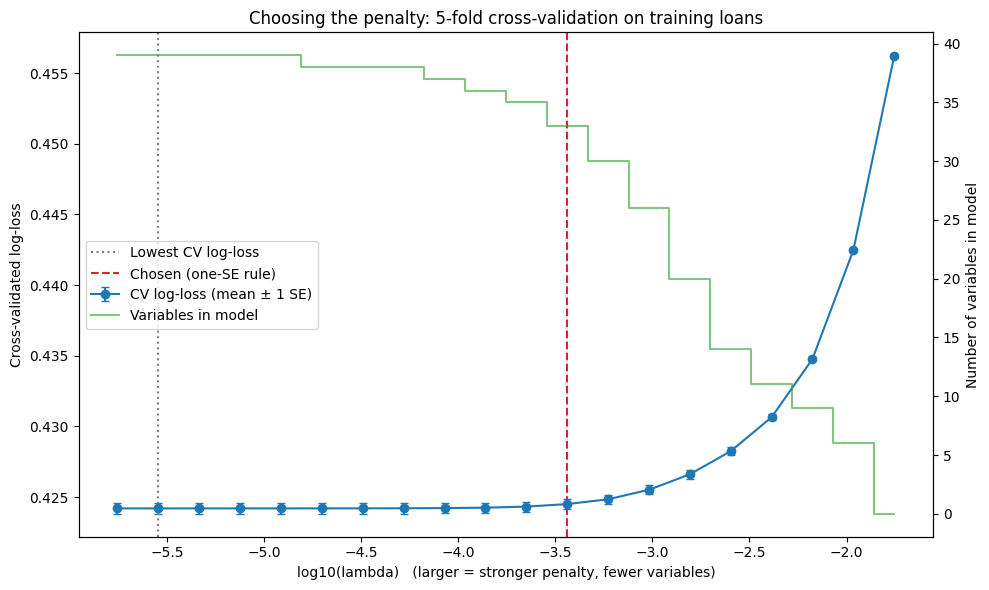

In [22]:
# Cross-validated log-loss along the penalty path

n_nonzero, w = [], None
for lam in lambdas:
    b0_, beta_ = fit_sign_constrained_l1(X_tr, y_train, lam, w0=w)
    w = np.concatenate([[b0_], beta_])
    n_nonzero.append(int(np.sum(beta_ < -1e-10)))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(np.log10(lambdas), cv_mean, yerr=cv_se, marker='o', capsize=3, color='tab:blue', label='CV log-loss (mean ± 1 SE)')
ax1.axvline(np.log10(lambdas[best]), color='grey', linestyle=':', label='Lowest CV log-loss')
ax1.axvline(np.log10(lam_chosen), color='tab:red', linestyle='--', label='Chosen (one-SE rule)')
ax1.set_xlabel('log10(lambda)   (larger = stronger penalty, fewer variables)')
ax1.set_ylabel('Cross-validated log-loss')

ax2 = ax1.twinx()
ax2.step(np.log10(lambdas), n_nonzero, where='mid', color='tab:green', alpha=0.6, label='Variables in model')
ax2.set_ylabel('Number of variables in model')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center left')
plt.title('Choosing the penalty: 5-fold cross-validation on training loans')
plt.tight_layout()
plt.savefig(FIGURES / 'l1_cv_path.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Calibration to the long-run average default rate

Predicted PDs are shifted so their average equals the long-run average of **yearly** default rates in the training period,
plus a 5 percentage point margin of conservatism.

In [23]:
# Average predicted PD before calibration
y_pred_probs = predict_pd(X_train_final, params)
avg_pred_pd = y_pred_probs.mean()
print(f"Initial Average PD: {avg_pred_pd:.4%}")

# Long-run average: mean of yearly default rates in the training period
annual_stats = (pd.DataFrame({'issue_year': issue_dates_train.dt.year.values, 'target': df_train['target'].values})
                .groupby('issue_year')['target'].agg(['mean', 'count']))
print(annual_stats)
lra_rate = annual_stats['mean'].mean()
print(f"\nLong-Run Average (LRA) Default Rate: {lra_rate:.4%}")

# Margin of conservatism
moc_buffer = 0.05
target_calibration_rate = np.clip(lra_rate + moc_buffer, 1e-9, 1 - 1e-9)

# Find the log-odds shift that makes the average predicted PD equal the target exactly
linear_train = X_train_final[params.index].to_numpy() @ params.to_numpy()
delta = brentq(lambda d: expit(linear_train + d).mean() - target_calibration_rate, -10, 10)
print(f"Calibration Delta (Log-Odds Shift): {delta:.4f}")

# Shift the intercept on a new copy of the coefficients
# (changing statsmodels' params in place does nothing under pandas copy-on-write)
params = params.copy()
params.loc['const'] = params.loc['const'] + delta

y_pred_probs_calibrated = predict_pd(X_train_final, params)
print(f"Target average PD (LRA + margin): {target_calibration_rate:.4%}")
print(f"New Calibrated Average PD: {y_pred_probs_calibrated.mean():.4%}")

Initial Average PD: 17.0250%
                mean   count
issue_year                  
2007        0.262023     603
2008        0.207271    2393
2009        0.136906    5281
2010        0.140145   12537
2011        0.151789   21721
2012        0.161973   53367
2013        0.155960  134804
2014        0.184498  223103

Long-Run Average (LRA) Default Rate: 17.5071%
Calibration Delta (Log-Odds Shift): 0.3752
Target average PD (LRA + margin): 22.5071%
New Calibrated Average PD: 22.5071%


## 11. Score scaling (600 points at 50:1 odds, 20 points to double the odds)

In [24]:
# Scorecard scaling parameters

target_score = 600
target_odds = 50
points_double_odds = 20

# Calculate Factor and Offset
factor = points_double_odds / np.log(2)
offset = target_score - (factor * np.log(target_odds))

print(f"Factor: {factor:.4f}")
print(f"Offset: {offset:.4f}")

Factor: 28.8539
Offset: 487.1229


In [25]:
# Generate scores for OOT validation data (using the calibrated coefficients)

log_odds = X_oot_final[params.index].to_numpy() @ params.to_numpy()

# Points to Double Odds (PDO) scaling: higher score = lower risk
df_oot_scored = df_oot.copy()
df_oot_scored['score'] = np.round(offset - factor * log_odds).astype(int)

# Probability of default
df_oot_scored['pd_prob'] = np.maximum(expit(log_odds), 0.0005)
df_oot_scored = df_oot_scored.dropna(subset=['pd_prob'])

print("\n--- OOT Score Distribution ---")
print(df_oot_scored['score'].describe())


--- OOT Score Distribution ---
count    894290.000000
mean        527.235841
std          20.003355
min         456.000000
25%         515.000000
50%         528.000000
75%         540.000000
max         599.000000
Name: score, dtype: float64


## 12. Out-of-time validation: discrimination, calibration and stability

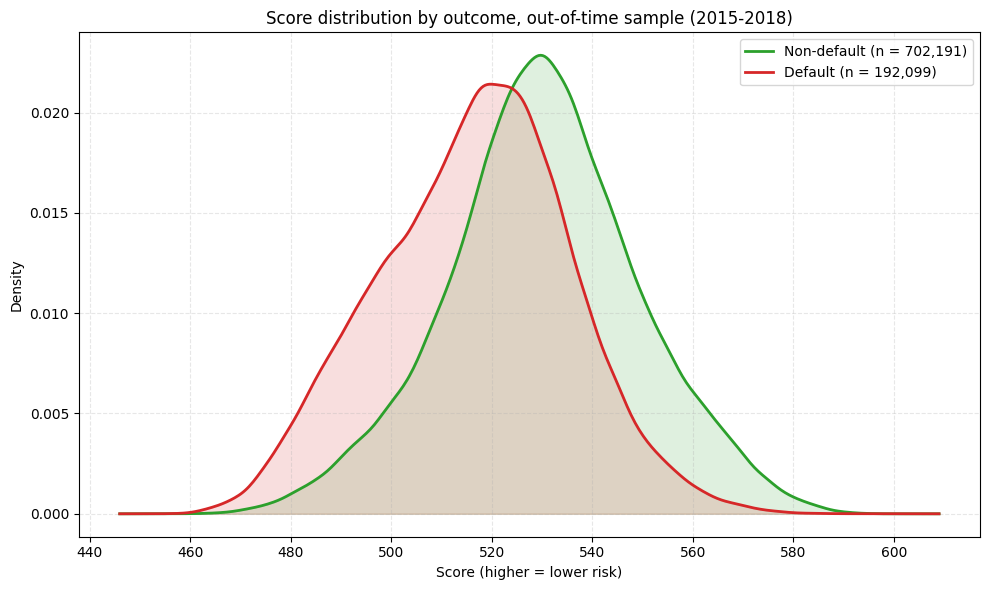

In [26]:
# Score distributions of defaulters and non-defaulters (kernel density estimates)
# A random sample of 100,000 loans per group keeps the density estimation fast

rng = np.random.default_rng(0)
grid = np.linspace(df_oot_scored['score'].min() - 10, df_oot_scored['score'].max() + 10, 400)

fig, ax = plt.subplots(figsize=(10, 6))
for label, flag, color in [('Non-default', 0, 'tab:green'), ('Default', 1, 'tab:red')]:
    scores = df_oot_scored.loc[df_oot_scored['target'] == flag, 'score'].to_numpy()
    sample = rng.choice(scores, size=min(100_000, len(scores)), replace=False)
    density = gaussian_kde(sample)(grid)
    ax.plot(grid, density, color=color, linewidth=2, label=f'{label} (n = {len(scores):,})')
    ax.fill_between(grid, density, alpha=0.15, color=color)

ax.set_title('Score distribution by outcome, out-of-time sample (2015-2018)')
ax.set_xlabel('Score (higher = lower risk)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'score_distribution_oot.png', dpi=150)
plt.show()

In [27]:
def calculate_ks_metric(df, target_col='target', prob_col='pd_prob'):
    """
    Calculates the Kolmogorov-Smirnov (KS) statistic using Scipy

    Measures the maximum separation between the cumulative distribution 
    functions of Goods (Non-Events) and Bads (Events)

    Args:
        df (pd.DataFrame): The dataframe containing target labels and predicted probabilities
        target_col (str, optional): Name of the binary target column. Defaults to 'target'
        prob_col (str, optional): Name of the predicted probability column. Defaults to 'pd_prob'

    Returns:
        float: The KS statistic (D), representing the maximum distance between the two distributions
    """


    # Separate the probabilities for Goods and Bads
    probs_bad = df[df[target_col] == 1][prob_col]
    probs_good = df[df[target_col] == 0][prob_col]
    
    # Calculate KS
    ks_stat, p_value = ks_2samp(probs_bad, probs_good)
    
    return ks_stat, p_value

ks_value, p_value = calculate_ks_metric(df_oot_scored)
print("KS test value: ", ks_value)
print("KS test p-value: ", p_value)

KS test value:  0.2766295477736583
KS test p-value:  0.0


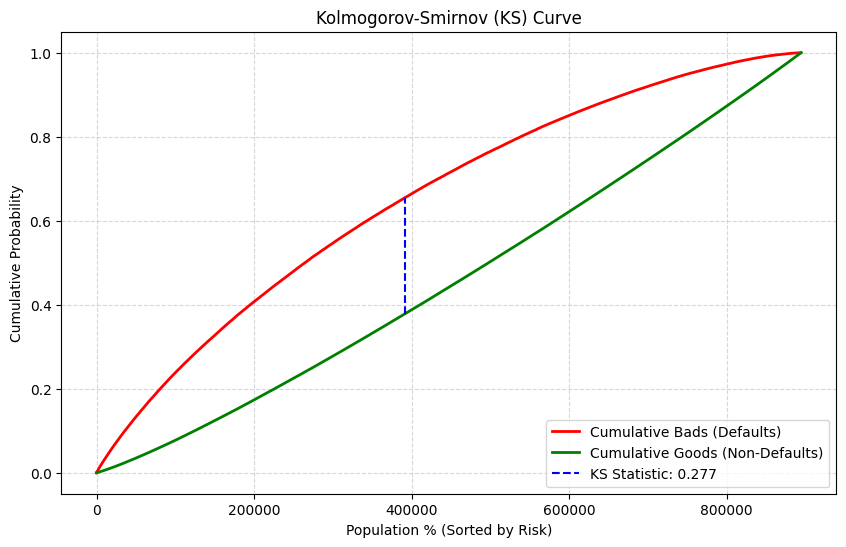

In [28]:
# Generate KS plot

# Sort by predicted probability
df_sorted = df_oot_scored.sort_values(by='pd_prob', ascending=False).reset_index(drop=True)

# Calculate Cumulative Counts
df_sorted['cum_bad'] = df_sorted['target'].cumsum()
df_sorted['cum_good'] = (1 - df_sorted['target']).cumsum()

df_sorted['cum_bad_pct'] = df_sorted['cum_bad'] / df_sorted['target'].sum()
df_sorted['cum_good_pct'] = df_sorted['cum_good'] / (1 - df_sorted['target']).sum()

df_sorted['ks_diff'] = abs(df_sorted['cum_bad_pct'] - df_sorted['cum_good_pct'])

max_ks_row = df_sorted.loc[df_sorted['ks_diff'].idxmax()]


# Plotting
plt.figure(figsize=(10, 6))

# Plot CDF
plt.plot(df_sorted['cum_bad_pct'], label='Cumulative Bads (Defaults)', color='red', linewidth=2)
plt.plot(df_sorted['cum_good_pct'], label='Cumulative Goods (Non-Defaults)', color='green', linewidth=2)

# Plot the KS Vertical Line
plt.vlines(x=max_ks_row.name, ymin=max_ks_row['cum_good_pct'], ymax=max_ks_row['cum_bad_pct'], 
           colors='blue', linestyles='dashed', label=f'KS Statistic: {ks_value:.3f}')

plt.title('Kolmogorov-Smirnov (KS) Curve')
plt.xlabel('Population % (Sorted by Risk)')
plt.ylabel('Cumulative Probability')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(FIGURES / 'ks_curve_oot.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Use df_oot_scored, where you saved the probabilities earlier
auc = roc_auc_score(df_oot_scored['target'], df_oot_scored['pd_prob'])
gini = 2 * auc - 1

print(f"AUC: {auc:.4f}")
print(f"Gini: {gini:.4f}")

AUC: 0.6939
Gini: 0.3878


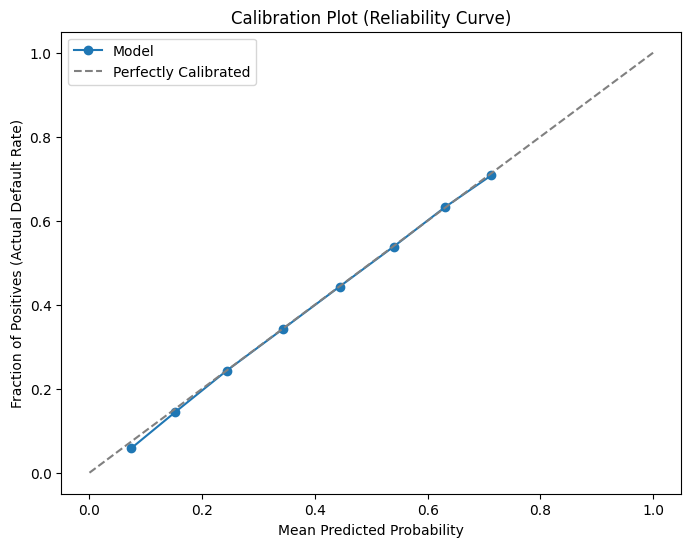

In [30]:
prob_true, prob_pred = calibration_curve(df_oot_scored['target'], df_oot_scored['pd_prob'], n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Default Rate)')
plt.title('Calibration Plot (Reliability Curve)')
plt.legend()
plt.show()

In [31]:
def calculate_psi(expected, actual, buckettype='bins', buckets=10, axis=0):
    '''Calculate the PSI (population stability index) across all variables'''
    
    def psi(expected_array, actual_array, buckets):
        # Define Breakpoints
        breakpoints = np.arange(0, buckets + 1) / (buckets) * 100

        if buckettype == 'bins':
            # Use unique breakpoints to avoid "monotonically increasing" errors
            breakpoints = np.unique(np.percentile(expected_array, breakpoints))
        
        # Calculate Frequencies
        # We clip actuals to ensure they fall within the expected range        
        min_val = expected_array.min()
        max_val = expected_array.max()
        actual_array_clipped = np.clip(actual_array, min_val, max_val)
        
        expected_percents = np.histogram(expected_array, breakpoints)[0] / len(expected_array)
        actual_percents = np.histogram(actual_array_clipped, breakpoints)[0] / len(actual_array)

        # Vectorized PSI Calculation (Fixes the DeprecationWarning)
        expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
        actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
        
        # Calculate for entire array at once (No loop!)
        psi_values = (expected_percents - actual_percents) * np.log(expected_percents / actual_percents)
        
        return np.sum(psi_values)

    if len(expected.shape) == 1:
        psi_values = np.empty(len(expected.shape))
    else:
        psi_values = np.empty(expected.shape[axis])

    if len(expected.shape) == 1:
        psi_values = psi(expected, actual, buckets)
    elif axis == 0:
        for i in range(0, expected.shape[1]):
            psi_values[i] = psi(expected[:,i], actual[:,i], buckets)
    elif axis == 1:
        for i in range(0, expected.shape[0]):
            psi_values[i] = psi(expected[i,:], actual[i,:], buckets)

    return psi_values

log_odds_train = X_train_final[params.index].to_numpy() @ params.to_numpy()

expected_scores = (offset - (factor * log_odds_train)).round().astype(int)

actual_scores = df_oot_scored['score']

psi_score = calculate_psi(expected_scores, actual_scores, buckets=10)
print(f"Population Stability Index (PSI), train vs OOT scores: {psi_score:.4f}")

Population Stability Index (PSI), train vs OOT scores: 0.0022


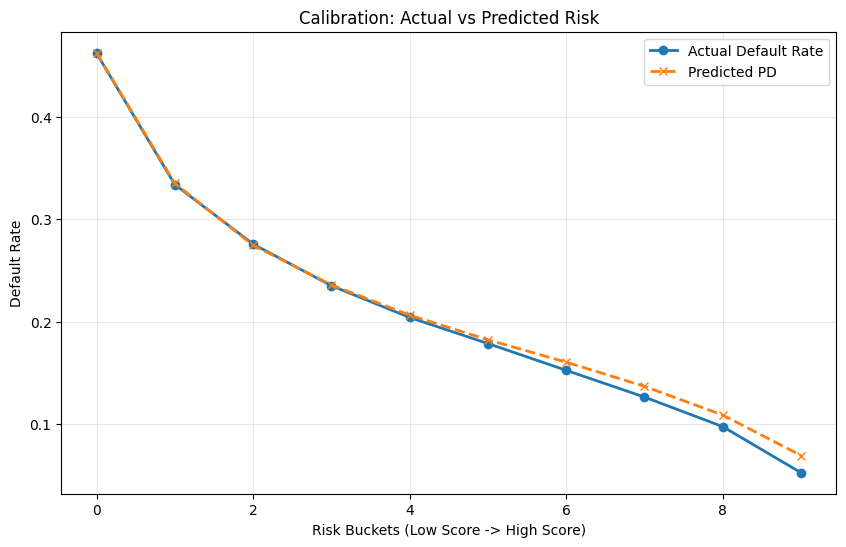

                  Actual_DR  Predicted_PD  Volume
bucket                                           
(455.999, 501.0]   0.462419      0.462861   94304
(501.0, 511.0]     0.333970      0.335132   89574
(511.0, 518.0]     0.275769      0.274591   96900
(518.0, 523.0]     0.235040      0.235805   87168
(523.0, 528.0]     0.203974      0.206275   97581
(528.0, 532.0]     0.178493      0.182129   77426
(532.0, 537.0]     0.152294      0.160278   87502
(537.0, 543.0]     0.126145      0.136647   85505
(543.0, 553.0]     0.097239      0.108552   93790
(553.0, 599.0]     0.052165      0.069001   84540

Largest gap between predicted and actual default rate: 1.7 percentage points
Average predicted PD (OOT): 22.00%   Actual default rate (OOT): 21.48%


In [32]:
# Create risk buckets (deciles)
df_oot_scored['bucket'] = pd.qcut(df_oot_scored['score'], q=10, duplicates='drop')

# Calculate Average PD vs Actual Default Rate per bucket
calibration = df_oot_scored.groupby('bucket', observed=False).agg({
    'target': 'mean',
    'pd_prob': 'mean',
    'score': 'count'
})

# Rename for clarity
calibration.columns = ['Actual_DR', 'Predicted_PD', 'Volume']

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(calibration)), calibration['Actual_DR'], marker='o', label='Actual Default Rate', linewidth=2)
plt.plot(range(len(calibration)), calibration['Predicted_PD'], marker='x', linestyle='--', label='Predicted PD', linewidth=2)
plt.title("Calibration: Actual vs Predicted Risk")
plt.xlabel("Risk Buckets (Low Score -> High Score)")
plt.ylabel("Default Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES / 'calibration_deciles_oot.png', dpi=150, bbox_inches='tight')
plt.show()

print(calibration)

calibration['Gap_pp'] = (calibration['Predicted_PD'] - calibration['Actual_DR']) * 100
print(f"\nLargest gap between predicted and actual default rate: {calibration['Gap_pp'].abs().max():.1f} percentage points")
print(f"Average predicted PD (OOT): {df_oot_scored['pd_prob'].mean():.2%}   Actual default rate (OOT): {df_oot_scored['target'].mean():.2%}")